Try using a denoising autoencoder to pretrain an image classifier. You can use MNIST (the simplest option), or a more complex image dataset such as CIFAR10 if you want a bigger challenge. Regardless of the dataset you’re using, follow these steps:
- Split the dataset into a training set and a test set. Train a deep denoising autoencoder on the full training set.
- Check that the images are fairly well reconstructed. Visualize the images that most activate each neuron in the coding layer.
- Build a classification DNN, reusing the lower layers of the autoencoder. Train it using only 500 images from the training set. Does it perform better with or without pretraining?


In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as T
import torchmetrics
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from collections import namedtuple

device = 'cuda'

/home/damian/New Folder/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ToTensor = T.Compose([T.ToImage(), T.ToDtype(dtype=torch.float32, scale=True)])

dataset = torchvision.datasets.CIFAR10(root='datas', train=True, transform=ToTensor)
train_dataset, valid_dataset = torch.utils.data.random_split(dataset, lengths=[45000, 5000])

class AEdataset(Dataset):
    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        x, _ = self.dataset[index]
        return x, x
    

train_loader = DataLoader(AEdataset(train_dataset), batch_size=32, shuffle=True)
valid_loader = DataLoader(AEdataset(valid_dataset), batch_size=32)

In [3]:
def eval_model(model, metric, valid_loader):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            
    return metric.compute()

def train_model(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs, 
                factor=0.5, patience=2, epoch_callback=None, temperature_decrease=False, train_encoder=True):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', factor, patience)
    history = {'train_loss':[], 'train_metrics':[], 'valid_metrics':[]}
    
    for epoch in range(n_epochs):
        total_loss = 0.0
        model.train()
        metric.reset()
        
        if train_encoder == False:
            model.encoder.eval()
            for p in model.encoder.parameters():
                p.requires_grad = False
                
        if epoch_callback is not None:
            epoch_callback(model, epoch)
            
        if temperature_decrease == True:
            model.temperature = 1 - 0.7 * (epoch/n_epochs)
            
        for index, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            train_metric = metric.compute().item()
            print(f'\rBatch: {index + 1}/{len(train_loader)}', end="")
            print(f', loss={total_loss/(index+1):.3f}', end="")
            print(f', {train_metric=:.2f}', end="")
            
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_metrics'].append(train_metric)
        val_metric = eval_model(model, metric, valid_loader)
        history['valid_metrics'].append(val_metric)
        
        scheduler.step(val_metric)
        print(f'\rEpoch: {epoch+1}/{n_epochs}\tTrain loss: {history["train_loss"][-1]:.3f}\tTrain metrics: {history['train_metrics'][-1]:.3f}\tValid metrics: {history['valid_metrics'][-1]:.3f}')
    
    return history

In [4]:
encoder = nn.Sequential(nn.Flatten(), nn.Linear(32*32*3, 1024), nn.ReLU(),
                        nn.Linear(1024, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU(),
                        nn.Linear(512, 256), nn.ReLU())
decoder = nn.Sequential(nn.Linear(256, 512), nn.ReLU() , nn.Linear(512, 512), nn.ReLU(),
                        nn.Linear(512, 1024), nn.ReLU(),
                        nn.Linear(1024, 32*32*3), nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(3, 32, 32)))
denoising_autoencoder = nn.Sequential(encoder, decoder).to(device)

nadam = torch.optim.NAdam(denoising_autoencoder.parameters())
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train_model(denoising_autoencoder, nadam, mse, rmse, train_loader, valid_loader, 25)

Epoch: 1/25	Train loss: 0.049	Train metrics: 0.221	Valid metrics: 0.193
Epoch: 2/25	Train loss: 0.037	Train metrics: 0.193	Valid metrics: 0.195
Epoch: 3/25	Train loss: 0.034	Train metrics: 0.186	Valid metrics: 0.181
Epoch: 4/25	Train loss: 0.033	Train metrics: 0.181	Valid metrics: 0.181
Epoch: 5/25	Train loss: 0.033	Train metrics: 0.181	Valid metrics: 0.181
Epoch: 6/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.180
Epoch: 7/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.180
Epoch: 8/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.180
Epoch: 9/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.179
Epoch: 10/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.180
Epoch: 11/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.180
Epoch: 12/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.179
Epoch: 13/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.179
Epoch: 14/25	Train loss: 0.032	Train metrics: 0.180	Valid me

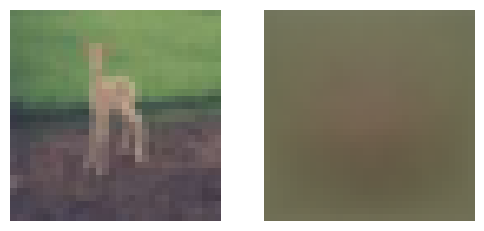

In [5]:
def plot_reconstruction(model, dataset, index=0):
    fig = plt.figure(figsize=(6, 6))

    an_image = dataset[index][0].permute(1, 2, 0)
    plt.subplot(1, 2, 1)
    plt.imshow(an_image)
    plt.axis('off')

    model.eval()
    with torch.no_grad():
        r_image = model(an_image.view(1, 32*32*3).to(device))
        
    if isinstance(r_image, tuple):
        r_image = r_image.output
        
    r_image = r_image.view(3, 32, 32)
    r_image = r_image.permute(1, 2, 0)
    r_image = r_image.cpu()
    r_image = torch.clamp(r_image, 0, 1)
    plt.subplot(1, 2, 2)
    plt.imshow(r_image)
    plt.axis('off')
    plt.show()
    
plot_reconstruction(denoising_autoencoder, valid_dataset, 0)

In [94]:
denoising_autoencoder.eval()
encoder.eval()
activations = encoder(valid_dataset[7][0].view(1, 3, 32, 32).to(device))
activation = encoder(valid_dataset[8][0].view(1, 3, 32, 32).to(device))
activations = torch.cat([activations, activations], dim=0)
activations.argmax(dim=1)

tensor([207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 2

In [6]:
def neuron_activation(encoder, dataset):
    encoder.eval()
    activations = encoder(dataset[0][0].view(1, 3, 32, 32).to(device))
    for i in range(len(dataset)):
        activations = torch.cat([activations, encoder(dataset[i][0].view(1, 3, 32, 32).to(device))])
        
    return activations

activations = neuron_activation(encoder, valid_dataset)

def neuron_favorite_image(activations):
    neuron_and_image_indexes = []
    only_images = []
    activations = activations.argmax(dim=0)
    for i in range(len(activations)):
        if activations[i].item() != 0 and activations[i].item() not in only_images:
            neuron_and_image_indexes.append((i, activations[i].item()))
            only_images.append(activations[i].item())
            
    return neuron_and_image_indexes

NI = neuron_favorite_image(activations)
    

[(1, 3407), (3, 1257), (48, 475), (69, 1085), (99, 187), (117, 2642), (118, 50), (163, 1533), (203, 2769), (209, 2606), (222, 3501), (227, 3399)]


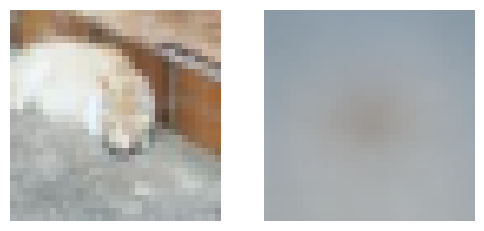

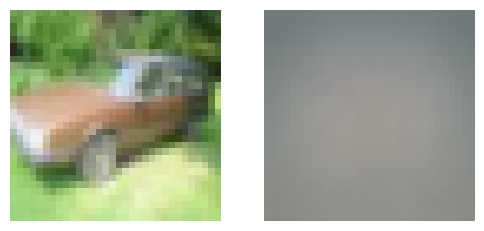

In [7]:
#only 2 neurons work! better to build sparse model
print(NI)
plot_reconstruction(denoising_autoencoder, valid_dataset, 2524)
plot_reconstruction(denoising_autoencoder, valid_dataset, 2841)

In [8]:
SparseOutput = namedtuple("SparseOutput", ['output', 'codings'])

class SparseDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Flatten(), nn.Linear(32*32*3, 1024), nn.ReLU(),
                                nn.Linear(1024, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU(),
                                nn.Linear(512, 256), nn.Sigmoid())
        self.decoder = nn.Sequential(nn.Linear(256, 512), nn.ReLU() , nn.Linear(512, 512), nn.ReLU(),
                                nn.Linear(512, 1024), nn.ReLU(),
                                nn.Linear(1024, 32*32*3), nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(3, 32, 32)))

    def forward(self, X):
        encodings = self.encoder(X)
        outputs = self.decoder(encodings)
        return SparseOutput(outputs, encodings)

sparse_model = SparseDenoisingAutoencoder().to(device)
nadam = torch.optim.NAdam(sparse_model.parameters())
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
mse = nn.MSELoss()

def mse_sparsity_loss(y_pred, y_target, target_sparsity=0.1, kl_weight=0.001, eps=1e-8):
    p = torch.tensor(target_sparsity, device=y_pred.codings.device)
    q = torch.clamp(y_pred.codings.mean(dim=0), eps, 1-eps)
    kl_div = p*torch.log(p/q) + (1-p)*torch.log((1-p)/(1-q))
    return mse(y_pred.output, y_target) + kl_weight * kl_div.sum()

history = train_model(sparse_model, nadam, mse_sparsity_loss, rmse, train_loader, valid_loader, 30)

Epoch: 1/30	Train loss: 0.048	Train metrics: 0.215	Valid metrics: 0.195
Epoch: 2/30	Train loss: 0.038	Train metrics: 0.194	Valid metrics: 0.192
Epoch: 3/30	Train loss: 0.034	Train metrics: 0.185	Valid metrics: 0.191
Epoch: 4/30	Train loss: 0.033	Train metrics: 0.181	Valid metrics: 0.179
Epoch: 5/30	Train loss: 0.032	Train metrics: 0.179	Valid metrics: 0.179
Epoch: 6/30	Train loss: 0.032	Train metrics: 0.177	Valid metrics: 0.176
Epoch: 7/30	Train loss: 0.030	Train metrics: 0.172	Valid metrics: 0.169
Epoch: 8/30	Train loss: 0.028	Train metrics: 0.166	Valid metrics: 0.165
Epoch: 9/30	Train loss: 0.027	Train metrics: 0.164	Valid metrics: 0.164
Epoch: 10/30	Train loss: 0.026	Train metrics: 0.161	Valid metrics: 0.160
Epoch: 11/30	Train loss: 0.026	Train metrics: 0.160	Valid metrics: 0.160
Epoch: 12/30	Train loss: 0.026	Train metrics: 0.159	Valid metrics: 0.159
Epoch: 13/30	Train loss: 0.025	Train metrics: 0.159	Valid metrics: 0.159
Epoch: 14/30	Train loss: 0.025	Train metrics: 0.159	Valid me

In [9]:
sparse_activations = neuron_activation(sparse_model.encoder, valid_dataset)
sparse_ni = neuron_favorite_image(sparse_activations)
print(sparse_ni)
print(len(sparse_ni))

[(0, 2642), (1, 417), (2, 475), (6, 4119), (7, 2151), (8, 3639), (9, 1755), (10, 2397), (12, 3365), (13, 864), (16, 1660), (19, 3162), (20, 3433), (23, 3327), (26, 3280), (33, 1247), (35, 2061), (39, 1533), (42, 4372), (45, 3256), (49, 3584), (52, 2840), (56, 4614), (59, 809), (60, 3372), (65, 2656), (66, 4937), (73, 1979), (78, 2489), (79, 4838), (82, 3823), (91, 4438), (95, 4012), (103, 3149), (115, 2470), (119, 1236), (129, 2254), (138, 999), (139, 4489), (152, 476), (166, 313), (190, 4082), (196, 2207), (201, 683), (204, 1198), (209, 4590), (225, 4653), (228, 734), (230, 2418), (248, 967), (249, 2443), (250, 98), (255, 4618)]
53


In [10]:
#all neurons work (I guess)
sparse_activations.argmax(dim=0)

tensor([2642,  417,  475, 2642,  417, 2642, 4119, 2151, 3639, 1755, 2397, 2642,
        3365,  864, 2151, 3639, 1660, 3639, 3639, 3162, 3433, 2642, 3639, 3327,
        2151,  864, 3280,  864, 2151, 3280, 2642,  475, 3639, 1247, 3639, 2061,
        3639, 3327, 3639, 1533, 4119, 1533, 4372, 3639,  417, 3256, 4119, 2397,
        3365, 3584, 2642, 2642, 2840, 3639, 2642, 3639, 4614, 3639,  475,  809,
        3372, 2642, 3639, 2151, 2642, 2656, 4937, 2642, 3639, 3433, 2642, 3639,
        3365, 1979, 2642,  864, 4119, 2656, 2489, 4838, 2397, 2397, 3823,  475,
        4119, 3327, 2642, 3639, 2642,  864, 2151, 4438, 3639, 3256, 4119, 4012,
        3639, 3433, 2642, 2642, 3639, 3639, 2151, 3149, 3639, 2642,  809, 3639,
        2642, 2151, 2642, 4614,  864, 4119, 2151, 2470, 2151, 2151, 2642, 1236,
        2642, 1533, 2642, 4372, 2151, 3639,  475, 4119, 2642, 2254, 3372, 3823,
        2642, 3639, 2642, 2151, 2642, 3256,  999, 4489, 3327, 3639, 2151, 3372,
        3280, 3639, 1660, 3639, 2642, 21

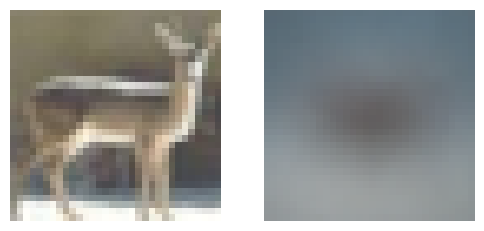

In [11]:
#still very blury
plot_reconstruction(sparse_model, valid_dataset, 1900)

classification task

In [47]:
cls_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
cls_valid_loader = DataLoader(valid_dataset, batch_size=32)

class EncoderCls(nn.Module):
    def __init__(self, encoder, num_classes):
       super().__init__()
       self.encoder = encoder
       self.dnn = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.BatchNorm1d(128),
                          nn.Dropout(0.1), nn.Linear(128, num_classes)).to(device)
       
    def forward(self, X):
        self.encoder.eval()
        with torch.no_grad():
            features = self.encoder(X)
        return self.dnn(features)
        
        
cls_model = EncoderCls(sparse_model.encoder, 10).to(device)


cls_model.eval()
with torch.no_grad():
    for X, y in cls_valid_loader:
        probas = cls_model(X.to(device)).argmax(dim=1)
        break
    
print(probas)
print(y)
print(torch.stack([y[i]==probas[i] for i in range(len(y))]).float().mean())

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')
tensor([4, 7, 9, 1, 0, 7, 5, 9, 7, 6, 4, 8, 8, 0, 5, 0, 6, 6, 5, 6, 6, 0, 6, 1,
        4, 3, 2, 5, 7, 7, 0, 1])
tensor(0.0938, device='cuda:0')


In [48]:
class RestrictedDataset(Dataset):
    def __init__(self, dataset, num_instances):
        self.dataset = [dataset[i] for i in range(num_instances)]
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        return self.dataset[index][0], self.dataset[index][1]

In [49]:
restricted_loader = DataLoader(RestrictedDataset(train_dataset, 500), batch_size=32, shuffle=True)
nadam = torch.optim.NAdam(params=cls_model.parameters())
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

history = train_model(cls_model, nadam, xentropy, accuracy, restricted_loader, cls_valid_loader, 500, train_encoder=False)

Epoch: 1/500	Train loss: 2.236	Train metrics: 0.184	Valid metrics: 0.152
Epoch: 2/500	Train loss: 2.083	Train metrics: 0.252	Valid metrics: 0.210
Epoch: 3/500	Train loss: 2.049	Train metrics: 0.270	Valid metrics: 0.240
Epoch: 4/500	Train loss: 2.023	Train metrics: 0.274	Valid metrics: 0.242
Epoch: 5/500	Train loss: 1.981	Train metrics: 0.300	Valid metrics: 0.240
Epoch: 6/500	Train loss: 1.993	Train metrics: 0.274	Valid metrics: 0.243
Epoch: 7/500	Train loss: 1.974	Train metrics: 0.304	Valid metrics: 0.256
Epoch: 8/500	Train loss: 1.973	Train metrics: 0.290	Valid metrics: 0.201
Epoch: 9/500	Train loss: 1.979	Train metrics: 0.288	Valid metrics: 0.234
Epoch: 10/500	Train loss: 1.956	Train metrics: 0.262	Valid metrics: 0.230
Epoch: 11/500	Train loss: 1.944	Train metrics: 0.288	Valid metrics: 0.237
Epoch: 12/500	Train loss: 1.916	Train metrics: 0.306	Valid metrics: 0.249
Epoch: 13/500	Train loss: 1.901	Train metrics: 0.302	Valid metrics: 0.244
Epoch: 14/500	Train loss: 1.855	Train metrics: 

In [188]:
#It seems to be same but with high error distribution now
cls_model.eval()
with torch.no_grad():
    for X, y in cls_train_loader:
        probas = cls_model(X.to(device)).argmax(dim=1)
        break
    
print(probas)
print(y)
print(torch.stack([y[i]==probas[i] for i in range(len(y))]).float().mean())

tensor([1, 6, 6, 0, 8, 8, 6, 1, 6, 0, 1, 0, 6, 6, 1, 6, 6, 1, 1, 1, 8, 8, 8, 1,
        1, 6, 8, 0, 0, 6, 1, 8], device='cuda:0')
tensor([1, 1, 6, 3, 5, 0, 7, 2, 9, 3, 5, 5, 5, 3, 3, 0, 4, 7, 2, 1, 9, 9, 0, 6,
        4, 4, 0, 9, 4, 4, 9, 3])
tensor(0.0938, device='cuda:0')


In [189]:
#orig denoising model
cls_model_2 = EncoderCls(encoder, 10).to(device)

nadam = torch.optim.NAdam(params=cls_model_2.parameters())
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

history = train_model(cls_model_2, nadam, xentropy, accuracy, restricted_loader, cls_valid_loader, 150, train_encoder=False)

Epoch: 1/150	Train loss: 2.301	Train metrics: 0.094	Valid metrics: 0.104
Epoch: 2/150	Train loss: 2.299	Train metrics: 0.146	Valid metrics: 0.104
Epoch: 3/150	Train loss: 2.284	Train metrics: 0.138	Valid metrics: 0.141
Epoch: 4/150	Train loss: 2.270	Train metrics: 0.188	Valid metrics: 0.157
Epoch: 5/150	Train loss: 2.259	Train metrics: 0.190	Valid metrics: 0.158
Epoch: 6/150	Train loss: 2.253	Train metrics: 0.184	Valid metrics: 0.158
Epoch: 7/150	Train loss: 2.253	Train metrics: 0.186	Valid metrics: 0.158
Epoch: 8/150	Train loss: 2.252	Train metrics: 0.186	Valid metrics: 0.156
Epoch: 9/150	Train loss: 2.250	Train metrics: 0.178	Valid metrics: 0.156
Epoch: 10/150	Train loss: 2.248	Train metrics: 0.186	Valid metrics: 0.143
Epoch: 11/150	Train loss: 2.249	Train metrics: 0.170	Valid metrics: 0.142
Epoch: 12/150	Train loss: 2.248	Train metrics: 0.184	Valid metrics: 0.157
Epoch: 13/150	Train loss: 2.246	Train metrics: 0.194	Valid metrics: 0.156
Epoch: 14/150	Train loss: 2.244	Train metrics: 

In [190]:
#19% accuracy for sparse and 15% for denoising
cls_model_2.eval()
with torch.no_grad():
    for X, y in cls_train_loader:
        probas = cls_model_2(X.to(device)).argmax(dim=1)
        break
    
print(probas)
print(y)
print(torch.stack([y[i]==probas[i] for i in range(len(y))]).float().mean())

tensor([6, 6, 0, 6, 6, 6, 0, 6, 6, 0, 6, 6, 0, 6, 8, 6, 6, 6, 6, 0, 0, 0, 0, 6,
        6, 0, 6, 6, 6, 9, 6, 6], device='cuda:0')
tensor([5, 0, 9, 6, 1, 5, 9, 1, 7, 7, 0, 6, 3, 1, 3, 5, 4, 0, 2, 7, 2, 8, 0, 6,
        7, 8, 1, 7, 7, 5, 4, 8])
tensor(0.1250, device='cuda:0')


/home/damian/New Folder/.venv/lib/python3.14/site-packages/torch/nn/modules/module.py:1778: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
